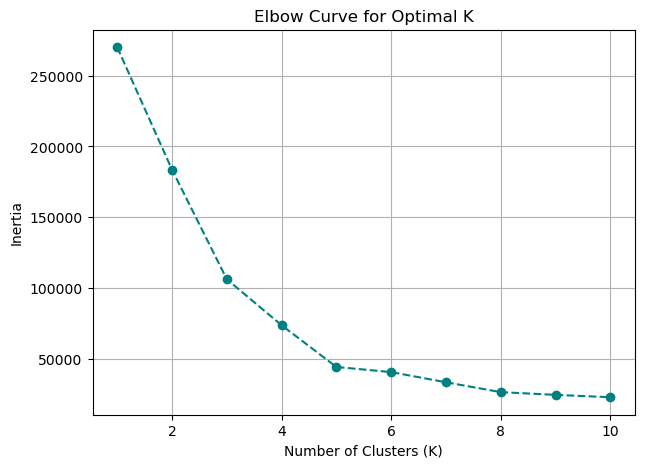

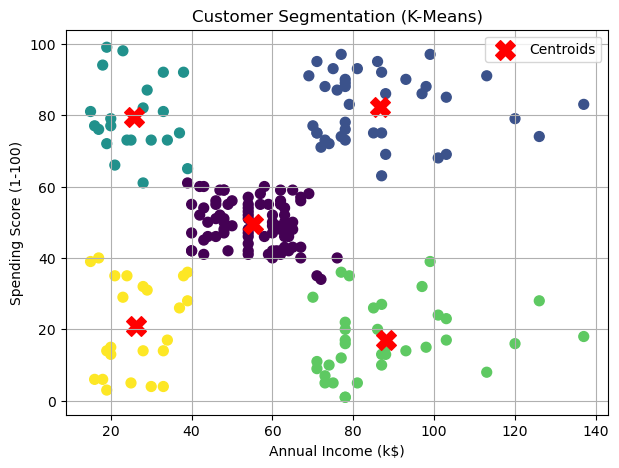

✅ Task 02 Completed Successfully
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [1]:
# ==========================================
# TASK 02: K-Means Clustering (Customers)
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
df = pd.read_csv("Mall_Customers.csv")

# ------------------------------------------
# 2. Select Features
# ------------------------------------------
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

# ------------------------------------------
# 3. Elbow Method
# ------------------------------------------
inertia_values = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, init="k-means++", random_state=42)
    model.fit(X)
    inertia_values.append(model.inertia_)

# Elbow Plot (slightly styled)
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--', color='teal')
plt.title("Elbow Curve for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# ------------------------------------------
# 4. Train Model
# ------------------------------------------
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(X)

# ------------------------------------------
# 5. Visualize Clusters
# ------------------------------------------
plt.figure(figsize=(7,5))

# Scatter with better colors
plt.scatter(
    X.iloc[:, 0], 
    X.iloc[:, 1], 
    c=clusters, 
    cmap='viridis',
    s=50
)

# Centroids (styled differently)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# 6. Add Cluster Labels
# ------------------------------------------
df["Cluster"] = clusters

print("✅ Task 02 Completed Successfully")
print(df.head())